<a href="https://colab.research.google.com/github/gujralvikas/hello-world/blob/master/build_makemore_mlp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# real in all the words
words = open('First.txt','r').read().splitlines()
words = [w.lower() for w in words]
words[:8]

['abhishek', 'aman', 'harsh', 'ayush', 'aditi', 'anjali', 'shubham', 'anushka']

In [3]:
len(words)

1165

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list((set(''.join(words)))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi ['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?
def build_dataset (words):
  X, Y =[], []

  for w in words:
    # print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print (X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])   # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte, Yte = build_dataset(words[n2:])   # 10%

torch.Size([6983, 3]) torch.Size([6983])
torch.Size([887, 3]) torch.Size([887])
torch.Size([882, 3]) torch.Size([882])


In [6]:
# MLP Neural Networks
n_embed = 5 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for similar results
C = torch.randn((vocab_size,n_embed),               generator=g)
W1 = torch.randn ((n_embed * block_size, n_hidden), generator=g) * (5/3) / ((n_embed * block_size) ** 0.5)  # 0.2
b1 = torch.randn (n_hidden,                         generator=g) * 0.01
W2 = torch.randn (n_hidden,vocab_size,              generator=g) * 0.01
b2 = torch.randn (vocab_size,                       generator=g) * 0
parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))  # number of parameters in total
for p in parameters:
  p.requires_grad = True

8762


In [7]:
# loss optimization through MLP

max_steps = 50000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X, Y

  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  # print(loss.item())

  #backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < max_steps / 2 else 0.01  # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 5000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  # break

      0/  50000: 3.2744
   5000/  50000: 1.8093
  10000/  50000: 1.5476
  15000/  50000: 1.8440
  20000/  50000: 1.8095
  25000/  50000: 1.3682
  30000/  50000: 1.1618
  35000/  50000: 1.1515
  40000/  50000: 1.8183
  45000/  50000: 1.4792


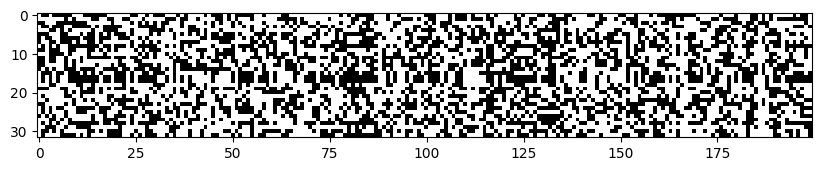

In [8]:
plt.figure(figsize=(10,10))
plt.imshow(h.abs()>0.99, cmap='gray', interpolation='nearest')

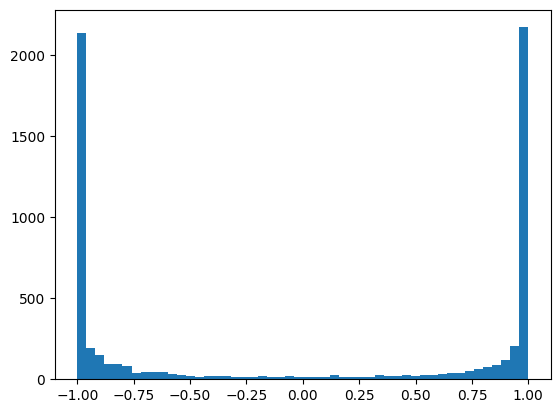

In [9]:
plt.hist(h.view(-1).tolist(),50);

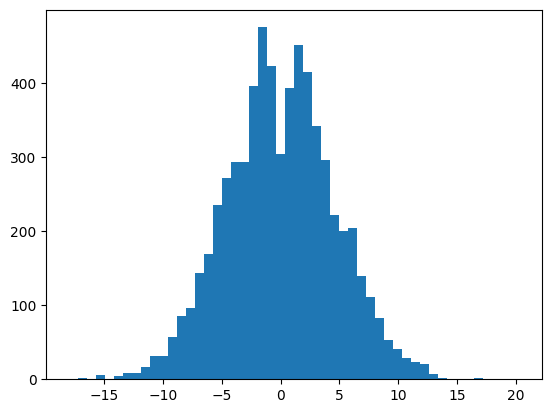

In [10]:
plt.hist(hpreact.view(-1).tolist(),50);

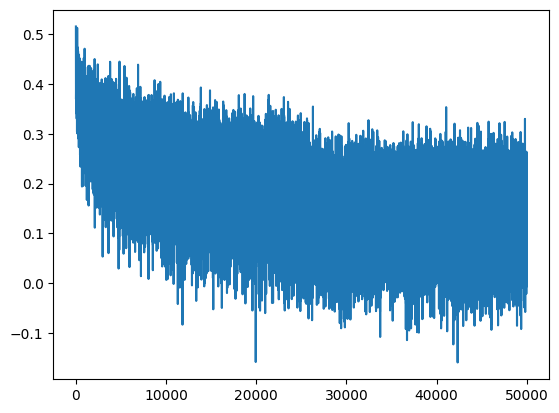

In [11]:
plt.plot(lossi)

In [12]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
      'train': (Xtr, Ytr),
      'val': (Xdev, Ydev),
      'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')
split_loss('test')

train 1.376530647277832
val 2.4514758586883545
test 2.6817238330841064


In [16]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range (20):
  out = []
  context = [0] * block_size # initiatilize with all ...
  while True:
    # forward pass the neural net
    emb = C[torch.tensor([context])] # (1, block_size, d)
    h = torch.tanh(emb.view(1,-1) @ W1 + b1)
    logits = h @ W2 + b2
    probs = F.softmax(logits, dim=1)
    # sample from the distribution
    ix = torch.multinomial(probs,num_samples=1,replacement=True, generator = g).item()
    # shift the context window and track the samples
    context = context[1:] + [ix]
    out.append(ix)
    # when we sample the special '.' token, break
    if ix == 0:
      break
  print(''.join(itos[i] for i in out[:-1])) # decode and pring the generated word

narendra
jyotsalyan
shreya
khalapu
shrajneet
priya
prashi
shreyash
maiimesh
him
sham
priya
shan
sulochan
vaishwanth
gitaruniman
supriya
sejal
siddhi
sahan
